# Dependencies

In [85]:
import datetime
import yaml
import numpy as np
import pandas as pd
import pathlib
import tensorflow as tf
import keras
from tensorflow.keras.callbacks import TensorBoard, EarlyStopping
import matplotlib.pyplot as plt

from src.data.prepare_data import prepare_non_rnn_data, prepare_rnn_data
from src.train.models import build_dmq_v0, build_dmq_v1, build_dmq
from src.train.losses import make_total_tilted_loss, tilted_loss, make_tilted_loss
from src.utils.evaluation import compute_oos_r1_score, compute_oos_r2_score

keras.utils.set_random_seed(1)
# =====================================================================
# Configuration
# =====================================================================
# Load config for defaults
with open("config/config_file.yaml", "r") as f:
    config = yaml.safe_load(f)

BASE_PATH = pathlib.Path('.')
data_config = config['data']
INPUT_FILES = data_config['input_files']
TARGET_FILE = data_config['target_file']
TARGETS_PATH = BASE_PATH/ 'data' / 'processed' / TARGET_FILE
INPUT_PATHS = [BASE_PATH / 'data' / 'processed' / file for file in INPUT_FILES]
START_DATE = data_config['start_date']

# Data configurations
TARGET_IDX = 2  # 0: Infl_yoy, 1: IP_yoy, 2: Unrate_yoy
TIME_STEPS = 12  # Number of quarters for RNN
YEAR = 1997     # Train cutoff year
VAL_MONTHS = 60   # Number of validation years
TEST_MONTHS = 60

QUANTILES = [0.05, 0.25, 0.5, 0.75, 0.95]
EPOCHS = 500
BATCH_SIZE = 4
LEARNING_RATE = 0.001

target_name_dict = {
    0: 'Infl_yoy',
    1: 'IP_yoy',
    2: 'Unrate_yoy',
}

target_name = target_name_dict[TARGET_IDX]
print(f"Experimental framework for target: {target_name}")

Experimental framework for target: Unrate_yoy


# Helper functions

In [20]:
def plot_and_evaluate_train_predictions(
        y_pred, 
        y_true,
        multi_quantile=False
):
    
    plt.plot(y_true, label='Actual values')
    if multi_quantile:
        for i in range(y_pred.shape[1]):
            plt.plot(y_pred[:,i], label=f'Predicted Q{i+1} values')
    else:
        plt.plot(y_pred, label='Predicted')
    plt.legend()
    plt.show()


def evaluate_quantile_predictions(
        y_pred,
        y_true,
        q_benchmarks,
        mean_benchmark
):
    r1_all = []
    for i,q in enumerate(QUANTILES):

        r1_q = compute_oos_r1_score(
            benchmark_pred=q_benchmarks[:,i],
            y_true=y_true.flatten(),
            y_pred=y_pred[:,i],
            q=q
        )
        r1_all.append(r1_q)
        print(f'R1 for q{q}: {r1_q}')

    print(f'Mean R1: {np.mean(r1_all)}')

    mean_preds = y_pred @ np.array([0.15, 0.225, 0.25, 0.225, 0.15]).reshape(-1,1)

    r2 = compute_oos_r2_score(
        y_true=y_true.flatten(),
        y_pred=mean_preds.flatten(),
        benchmark=mean_benchmark
    )

    print(f'R2 score: {r2}')



# Static data

In [69]:
non_rnn_data = prepare_non_rnn_data(
    targets_path=TARGETS_PATH,
    input_paths=INPUT_PATHS,
    start_date=START_DATE,
    train_cutoff_year=YEAR,
    val_months=VAL_MONTHS,
    test_months=TEST_MONTHS,
)

(
    X_train,
    X_val,
    X_test,
    targets_train,
    targets_val,
    targets_test
) = non_rnn_data

print(targets_train.shape, targets_val.shape, targets_test.shape)

targets_train = targets_train.copy()
targets_val   = targets_val.copy()
targets_test  = targets_test.copy()

X_train_full = pd.concat([X_train, X_val])
targets_train_full = pd.concat([targets_train, targets_val])
y_train = targets_train[target_name]
y_train_full = targets_train_full[target_name]
y_val = targets_val[target_name]
y_test = targets_test[target_name]
mq_y_train_full = np.repeat(y_train_full.values.reshape(-1,1), 5, axis=1)
mq_y_val = np.repeat(y_val.values.reshape(-1,1), 5, axis=1)

(384, 3) (60, 3) (60, 3)


In [22]:
[X.shape for X in X_train_full]

[(444, 15),
 (444, 31),
 (444, 10),
 (444, 8),
 (444, 13),
 (444, 21),
 (444, 20),
 (444, 4)]

## Inspect data

In [4]:
from statsmodels.tsa.stattools import adfuller

targets = pd.concat([targets_train, targets_val, targets_test])

In [5]:
targets

,Infl_yoy,IP_yoy,Unrate_yoy
date,,,
1961-01-01,1.587603,-8.832737,23.841102
1961-02-01,1.451502,-8.060415,36.290549
1961-03-01,1.451502,-6.551866,24.512246
1961-04-01,0.909863,-3.721446,29.725152
1961-05-01,0.908944,-2.078615,33.085424
...,...,...,...
2002-08-01,1.732371,1.530708,15.123097
2002-09-01,1.504626,2.123361,13.102826
2002-10-01,2.006756,2.189399,7.275935


<Axes: xlabel='date'>

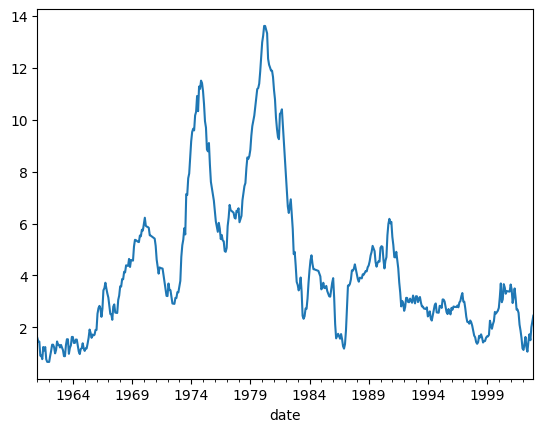

In [6]:
targets['Infl_yoy'].plot()

In [7]:
results = adfuller(targets['Infl_yoy'])
print(f'p-value: {results[1]}')

p-value: 0.056022008899130296


<Axes: xlabel='date'>

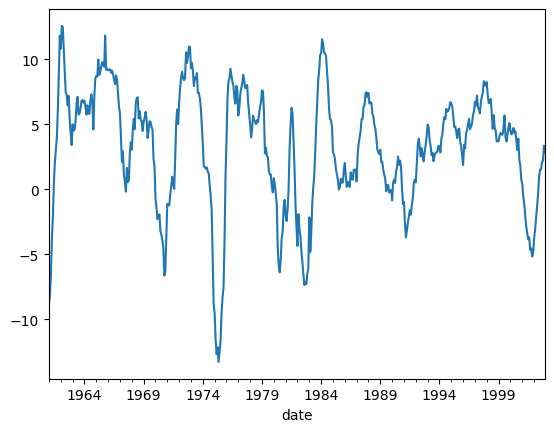

In [8]:
targets['IP_yoy'].plot()

In [9]:
results = adfuller(targets['IP_yoy'])
print(f'p-value: {results[1]}')

p-value: 4.971055701128377e-05


<Axes: xlabel='date'>

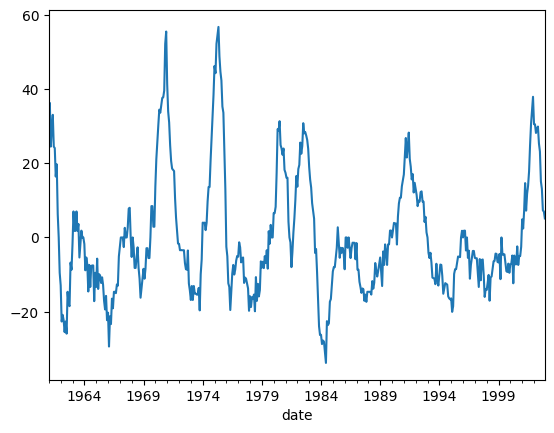

In [10]:
targets['Unrate_yoy'].plot()

# Baselines

## Benchmarks

In [11]:
benchmark_dict = {
    0: r'predictions\concatenated\benchmark_preds\all_models_predictions_us_4q_Infl_yoy.csv',
    1: r'predictions\concatenated\benchmark_preds\all_models_predictions_us_4q_IP_yoy.csv',
    2: r'predictions\concatenated\benchmark_preds\all_models_predictions_us_4q_Unrate_yoy.csv'
}

benchmarks = pd.read_csv(benchmark_dict[TARGET_IDX], index_col=0, parse_dates=True)
benchmarks.head()

,Naive_Q5,Naive_Q25,Naive_Q50,Naive_Q75,Naive_Q95,Naive_Mean,VG_Q5,VG_Q25,VG_Q50,VG_Q75,VG_Q95
1998-01-01,-6.057545,0.605392,4.260074,6.670523,9.478337,3.362516,1.569754,3.537836,4.854196,5.957735,8.311031
1998-02-01,-6.057545,0.605392,4.260074,6.670523,9.478337,3.362516,1.392625,3.387437,4.617369,5.770241,8.288657
1998-03-01,-6.057545,0.605392,4.260074,6.670523,9.478337,3.362516,2.008946,3.571253,4.841401,5.943525,8.446140
1998-04-01,-6.057545,0.605392,4.260074,6.670523,9.478337,3.362516,1.861540,3.538966,4.700794,5.768713,8.315119
1998-05-01,-6.057545,0.605392,4.260074,6.670523,9.478337,3.362516,1.780310,3.447440,4.742556,5.915668,8.470264


In [13]:
naive_preds = benchmarks.loc[X_test.index, 'Naive_Q5': 'Naive_Q95']
for i, q in enumerate(QUANTILES):
    r1_q = compute_oos_r1_score(
        benchmark_pred=naive_preds.iloc[:,i],
        y_true=y_test,
        y_pred=naive_preds.iloc[:,i],
        q=q
    )
    print(r1_q)

0.0
0.0
0.0
0.0
0.0


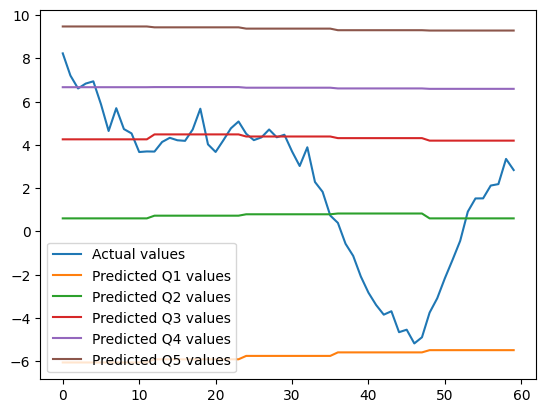

In [22]:
plot_and_evaluate_train_predictions(
    y_pred=naive_preds.values,
    y_true=y_test.values,
    multi_quantile=True
)

In [15]:
benchmarks.columns = benchmarks.columns.str.replace(
    r'VG|IAR|UAR',
    'LIT',
    regex=True
)
lit_preds = benchmarks.loc[X_test.index, 'LIT_Q5': 'LIT_Q95']
for i, q in enumerate(QUANTILES):
    r1_q = compute_oos_r1_score(
        benchmark_pred=naive_preds.iloc[:,i],
        y_true=y_test,
        y_pred=lit_preds.iloc[:,i],
        q=q
    )
    print(r1_q)


-15.908007282392989
7.296923324901683
5.253993947177538
10.235849169797106
12.54230805658879


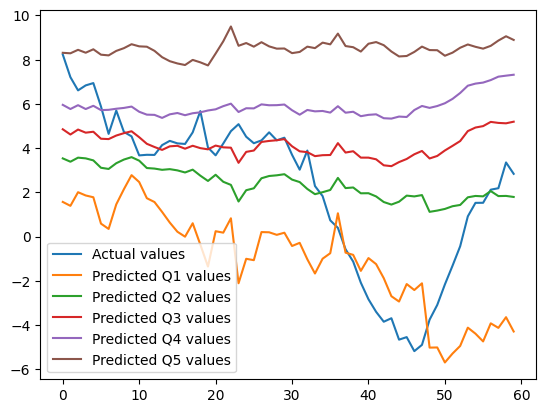

In [21]:
plot_and_evaluate_train_predictions(
    y_pred=lit_preds.values,
    y_true=y_test.values,
    multi_quantile=True
)

## Check training loss at init for a network that predicts the median

In [ ]:
quantile = 0.5
subsample_size = X_train_full.shape[0]
learning_rate = 1e-5

for quantile in [0.05, 0.25, 0.5, 0.75, 0.95]:
    model_1 = keras.Sequential(
        [
            keras.layers.Dense(
                32,
                kernel_initializer='zeros',
                bias_initializer='zeros'
            ),
            keras.layers.Dense(
                1, 
                bias_initializer=keras.initializers.Constant(float(y_train_full.quantile(quantile)))
            )
        ]
    )
    model_1.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate), 
        loss=make_tilted_loss(quantile)
    )

    history = model_1.fit(
        x=X_train_full.values[:subsample_size],
        y=y_train_full.values[:subsample_size],
        epochs=1, 
        batch_size=4,
        validation_data=(X_val, y_val),
        # callbacks=[
        #     keras.callbacks.EarlyStopping(
        #         monitor='val_loss',
        #         min_delta=1e-4,
        #         patience=20,
        #         restore_best_weights=False
        #     )
        # ]
    )

    # Training loss at init should be 
    y_train_full_tf = tf.constant(y_train_full.values)
    y_mean_tf = tf.constant(y_train_full.quantile(quantile))
    expected_loss = tilted_loss(y_train_full_tf, y_mean_tf, q=quantile)

    print(
        (f'Initial loss: {np.round(history.history['loss'][0],4)}. '
        f'Expected: {np.round(expected_loss, 4)}')
    )

# plt.plot(history.history['loss'], label='Training loss')
# plt.plot(history.history['val_loss'], label='Validation loss')
# plt.legend()
# plt.show()

Loss works, we can move on. Note that to check the initial loss the kernel must be initialized as zero.

## Overfit on a small number of examples

In [ ]:
quantile = 0.5
subsample_size = 10
lr=3e-4
model = keras.Sequential(
    [
        keras.layers.Dense(
            512,
            activation='relu'
        ),
        # keras.layers.LayerNormalization(),
        # keras.layers.Dense(
        #     128, 
        #     activation=activation,
        # ),
        # keras.layers.LayerNormalization(),
        # keras.layers.Dense(
        #     64, 
        #     activation=activation,
        # ),
        # keras.layers.LayerNormalization(),
        # keras.layers.Dense(
        #     32, 
        #     activation='relu',
        # ),
        keras.layers.Dense(
            1, 
            bias_initializer=keras.initializers.Constant(float(y_train_full.quantile(quantile)))
        )
    ]
)
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=lr), 
    loss=make_tilted_loss(quantile)
)

history = model.fit(
    x=X_train_full.values[:subsample_size],
    y=y_train_full.values[:subsample_size],
    epochs=100, 
    batch_size=8,
    validation_data=(X_val, y_val),
    # callbacks=[
    #     EarlyStopping(
    #         min_delta=1e-4,
    #         patience=20
    #     )
    # ]
)

plt.plot(history.history['loss'], label='Training loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.legend()
plt.show()

y_pred = model.predict(X_train_full[:subsample_size])
plot_and_evaluate_train_predictions(
    y_pred=y_pred, 
    y_true=y_train_full.values.flatten()[:subsample_size]
    )

## Overfit on the whole training sample

In [ ]:
quantile = 0.5
lr = 3e-4
model = keras.Sequential(
    [
        keras.layers.Dense(
            512, 
            activation='relu'
        ),
        keras.layers.LayerNormalization(),
        keras.layers.Dense(
            256, 
            activation='relu',
        ),
        keras.layers.LayerNormalization(),
        keras.layers.Dense(
            128, 
            activation='relu',
        ),
        keras.layers.LayerNormalization(),
        keras.layers.Dense(
            64, 
            activation='relu',
        ),
        keras.layers.Dense(
            1, 
            bias_initializer=keras.initializers.Constant(float(y_train_full.quantile(quantile)))
        )
    ]
)
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=lr), 
    loss=make_tilted_loss(quantile)
)

history = model.fit(
    x=X_train.values,
    y=y_train.values,
    epochs=100, 
    batch_size=8,
    validation_data=(X_val, y_val),
    # callbacks=[
    #     EarlyStopping(
    #         min_delta=1e-4,
    #         patience=20
    #     )
    # ]
)

plt.plot(history.history['loss'], label='Training loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.legend()
plt.show()

y_pred = model.predict(X_train)
plot_and_evaluate_train_predictions(
    y_pred=y_pred, 
    y_true=y_train.values.flatten()
    )

y_pred = model.predict(X_test)
plot_and_evaluate_train_predictions(
    y_pred=y_pred,
    y_true=y_test.values.flatten() 
    )

## Generalize

In [ ]:
quantile = 0.5
lr = 1e-4
l2 = 5e-1
do = 0.0
model = keras.Sequential(
    [
        keras.layers.Dense(
            64, 
            kernel_regularizer=keras.regularizers.L2(l2),
            bias_regularizer=keras.regularizers.L2(l2),
        ),
        keras.layers.LayerNormalization(),
        keras.layers.Activation(keras.activations.leaky_relu),
        keras.layers.Dropout(do),
        keras.layers.Dense(
            32, 
            kernel_regularizer=keras.regularizers.L2(l2),
            bias_regularizer=keras.regularizers.L2(l2)
        ),
        keras.layers.LayerNormalization(),
        keras.layers.Activation(keras.activations.leaky_relu),
        keras.layers.Dropout(do),
        keras.layers.Dense(
            16, 
            kernel_regularizer=keras.regularizers.L2(l2),
            bias_regularizer=keras.regularizers.L2(l2)
        ),
        keras.layers.Activation(keras.activations.leaky_relu),
        keras.layers.Dense(
            1, 
            bias_initializer=keras.initializers.Constant(float(y_train_full.quantile(quantile))),
            kernel_regularizer=keras.regularizers.L2(l2),
            bias_regularizer=keras.regularizers.L2(l2)
        )
    ]
)
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=lr), 
    loss=make_tilted_loss(quantile)
)

history = model.fit(
    x=X_train.values,
    y=y_train.values,
    epochs=200, 
    batch_size=8,
    validation_data=(X_val, y_val),
    callbacks=[
        EarlyStopping(
            min_delta=1e-3,
            patience=5
        )
    ],
    shuffle=True
)

plt.plot(history.history['loss'], label='Training loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.legend()
plt.show()

In [ ]:
y_pred = model.predict(X_train)
plot_and_evaluate_train_predictions(
    y_pred=y_pred, 
    y_true=y_train.values.flatten()
    )

y_pred = model.predict(X_test)
plot_and_evaluate_train_predictions(
    y_pred=y_pred,
    y_true=y_test.values.flatten() 
    )

Notes:
- Need to train feed-forward models with shuffle set to True for generalization
- I think selecting a random subset of training data for validation with a 
    buffer (reserving the last data for training) improves generalization
- l2 needs to be between (8e-1, 9e-1) (9e-1 is too much) 8e-1 is good

### Train on augmented data (jitter)

In [ ]:
quantile = 0.5
lr = 1e-4
l2 = 8e-1
do = 0.0
model = keras.Sequential(
    [
        keras.layers.Dense(
            64, 
            kernel_regularizer=keras.regularizers.L2(l2),
            bias_regularizer=keras.regularizers.L2(l2),
        ),
        keras.layers.LayerNormalization(),
        keras.layers.Activation(keras.activations.leaky_relu),
        keras.layers.Dropout(do),
        keras.layers.Dense(
            32, 
            kernel_regularizer=keras.regularizers.L2(l2),
            bias_regularizer=keras.regularizers.L2(l2)
        ),
        keras.layers.LayerNormalization(),
        keras.layers.Activation(keras.activations.leaky_relu),
        keras.layers.Dropout(do),
        keras.layers.Dense(
            16, 
            kernel_regularizer=keras.regularizers.L2(l2),
            bias_regularizer=keras.regularizers.L2(l2)
        ),
        keras.layers.Activation(keras.activations.leaky_relu),
        keras.layers.Dense(
            1, 
            bias_initializer=keras.initializers.Constant(float(y_train_full.quantile(quantile))),
            kernel_regularizer=keras.regularizers.L2(l2),
            bias_regularizer=keras.regularizers.L2(l2)
        )
    ]
)
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=lr), 
    loss=make_tilted_loss(quantile)
)

history = model.fit(
    x=X_train_aug.values,
    y=y_train_aug.values,
    epochs=200, 
    batch_size=8,
    validation_data=(X_val, y_val),
    callbacks=[
        EarlyStopping(
            min_delta=1e-3,
            patience=5
        )
    ],
    shuffle=True
)

plt.plot(history.history['loss'], label='Training loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.legend()
plt.show()

In [ ]:
y_pred = model.predict(X_train_aug)
plot_and_evaluate_train_predictions(
    y_pred=y_pred, 
    y_true=y_train_aug.values.flatten()
    )

y_pred = model.predict(X_test)
plot_and_evaluate_train_predictions(
    y_pred=y_pred,
    y_true=y_test.values.flatten() 
    )

### Augment the validation data as well for a larger validation set

In [ ]:
quantile = 0.5
lr = 1e-4
l2 = 8e-1
do = 0.0
model = keras.Sequential(
    [
        keras.layers.Dense(
            256, 
            kernel_regularizer=keras.regularizers.L2(l2),
            bias_regularizer=keras.regularizers.L2(l2),
        ),
        keras.layers.LayerNormalization(),
        keras.layers.Activation(keras.activations.leaky_relu),
        keras.layers.Dropout(do),
        keras.layers.Dense(
            128, 
            kernel_regularizer=keras.regularizers.L2(l2),
            bias_regularizer=keras.regularizers.L2(l2)
        ),
        keras.layers.LayerNormalization(),
        keras.layers.Activation(keras.activations.leaky_relu),
        keras.layers.Dropout(do),
        keras.layers.Dense(
            64, 
            kernel_regularizer=keras.regularizers.L2(l2),
            bias_regularizer=keras.regularizers.L2(l2)
        ),
        keras.layers.Activation(keras.activations.leaky_relu),
        keras.layers.Dense(
            1, 
            bias_initializer=keras.initializers.Constant(float(y_train_full.quantile(quantile))),
            kernel_regularizer=keras.regularizers.L2(l2),
            bias_regularizer=keras.regularizers.L2(l2)
        )
    ]
)
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=lr), 
    loss=make_tilted_loss(quantile)
)

history = model.fit(
    x=X_train_aug.values,
    y=y_train_aug.values,
    epochs=200, 
    batch_size=8,
    validation_data=(X_val_aug, y_val_aug),
    callbacks=[
        EarlyStopping(
            min_delta=1e-4,
            patience=20
        )
    ],
    shuffle=True
)

plt.plot(history.history['loss'], label='Training loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.legend()

In [ ]:
y_pred = model.predict(X_train_aug)
plot_and_evaluate_train_predictions(
    y_pred=y_pred, 
    y_true=y_train_aug.values.flatten()
    )

y_pred = model.predict(X_test)
plot_and_evaluate_train_predictions(
    y_pred=y_pred,
    y_true=y_test.values.flatten() 
    )

### Make a larger validation set

In [ ]:
X_val_aug_l.shape

In [ ]:
quantile = 0.5
lr = 1e-4
l2 = 8e-1
do = 0.0
model = keras.Sequential(
    [
        keras.layers.Dense(
            256, 
            kernel_regularizer=keras.regularizers.L2(l2),
            bias_regularizer=keras.regularizers.L2(l2),
        ),
        keras.layers.LayerNormalization(),
        keras.layers.Activation(keras.activations.leaky_relu),
        keras.layers.Dropout(do),
        keras.layers.Dense(
            128, 
            kernel_regularizer=keras.regularizers.L2(l2),
            bias_regularizer=keras.regularizers.L2(l2)
        ),
        keras.layers.LayerNormalization(),
        keras.layers.Activation(keras.activations.leaky_relu),
        keras.layers.Dropout(do),
        keras.layers.Dense(
            64, 
            kernel_regularizer=keras.regularizers.L2(l2),
            bias_regularizer=keras.regularizers.L2(l2)
        ),
        keras.layers.Activation(keras.activations.leaky_relu),
        keras.layers.Dense(
            1, 
            bias_initializer=keras.initializers.Constant(float(y_train_full.quantile(quantile))),
            kernel_regularizer=keras.regularizers.L2(l2),
            bias_regularizer=keras.regularizers.L2(l2)
        )
    ]
)
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=lr), 
    loss=make_tilted_loss(quantile)
)

history = model.fit(
    x=X_train_aug.values,
    y=y_train_aug.values,
    epochs=200, 
    batch_size=8,
    validation_data=(X_val_aug_l, y_val_aug_l),
    callbacks=[
        EarlyStopping(
            min_delta=1e-4,
            patience=20
        )
    ],
    shuffle=True
)

plt.plot(history.history['loss'], label='Training loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.legend()

In [ ]:
y_pred = model.predict(X_train_aug)
plot_and_evaluate_train_predictions(
    y_pred=y_pred, 
    y_true=y_train_aug.values.flatten()
    )

y_pred = model.predict(X_test)
plot_and_evaluate_train_predictions(
    y_pred=y_pred,
    y_true=y_test.values.flatten() 
    )

### Even larger augmentation

In [ ]:
# Shift up
X_train_shift_up = add_noise(X_train, loc=0.05)
X_train_shift_down = add_noise(X_train, loc=-0.05)

X_train_aug_2 = pd.concat([X_train_shift_up, X_train_shift_down, X_train_aug], ignore_index=True)
y_train_aug_2 = pd.concat([y_train, y_train, y_train_aug], ignore_index=True)

X_train_aug_2.shape, y_train_aug_2.shape

In [ ]:
quantile = 0.5
lr = 1e-4
l2 = 8e-1
do = 0.0
model = keras.Sequential(
    [
        keras.layers.Dense(
            256, 
            kernel_regularizer=keras.regularizers.L2(l2),
            bias_regularizer=keras.regularizers.L2(l2),
        ),
        keras.layers.LayerNormalization(),
        keras.layers.Activation(keras.activations.leaky_relu),
        keras.layers.Dropout(do),
        keras.layers.Dense(
            128, 
            kernel_regularizer=keras.regularizers.L2(l2),
            bias_regularizer=keras.regularizers.L2(l2)
        ),
        keras.layers.LayerNormalization(),
        keras.layers.Activation(keras.activations.leaky_relu),
        keras.layers.Dropout(do),
        keras.layers.Dense(
            64, 
            kernel_regularizer=keras.regularizers.L2(l2),
            bias_regularizer=keras.regularizers.L2(l2)
        ),
        keras.layers.Activation(keras.activations.leaky_relu),
        keras.layers.Dense(
            1, 
            bias_initializer=keras.initializers.Constant(float(y_train_full.quantile(quantile))),
            kernel_regularizer=keras.regularizers.L2(l2),
            bias_regularizer=keras.regularizers.L2(l2)
        )
    ]
)
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=lr), 
    loss=make_tilted_loss(quantile)
)

history = model.fit(
    x=X_train_aug_2.values,
    y=y_train_aug_2.values,
    epochs=200, 
    batch_size=8,
    validation_data=(X_val_aug, y_val_aug),
    callbacks=[
        EarlyStopping(
            min_delta=1e-4,
            patience=20
        )
    ],
    shuffle=True
)

plt.plot(history.history['loss'], label='Training loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.legend()

In [ ]:
y_pred = model.predict(X_train_aug_2)
plot_and_evaluate_train_predictions(
    y_pred=y_pred, 
    y_true=y_train_aug_2.values.flatten()
    )

y_pred = model.predict(X_test)
plot_and_evaluate_train_predictions(
    y_pred=y_pred,
    y_true=y_test.values.flatten() 
    )

### Sample from low inflation period

In [ ]:
X_train_aug = pd.concat(
    [
        add_noise(X_train[-120:]),
        add_noise(X_train[-120:]),
        X_train
    ],
    ignore_index=True
)
y_train_aug = pd.concat([y_train[-120:]]*2 + [y_train], ignore_index=True)

In [ ]:
quantile = 0.5
lr = 1e-4
l2 = 8e-1
do = 0.0
model = keras.Sequential(
    [
        keras.layers.Dense(
            256, 
            kernel_regularizer=keras.regularizers.L2(l2),
            bias_regularizer=keras.regularizers.L2(l2),
        ),
        keras.layers.LayerNormalization(),
        keras.layers.Activation(keras.activations.leaky_relu),
        keras.layers.Dropout(do),
        keras.layers.Dense(
            128, 
            kernel_regularizer=keras.regularizers.L2(l2),
            bias_regularizer=keras.regularizers.L2(l2)
        ),
        keras.layers.LayerNormalization(),
        keras.layers.Activation(keras.activations.leaky_relu),
        keras.layers.Dropout(do),
        keras.layers.Dense(
            64, 
            kernel_regularizer=keras.regularizers.L2(l2),
            bias_regularizer=keras.regularizers.L2(l2)
        ),
        keras.layers.Activation(keras.activations.leaky_relu),
        keras.layers.Dense(
            1, 
            bias_initializer=keras.initializers.Constant(float(y_train_full.quantile(quantile))),
            kernel_regularizer=keras.regularizers.L2(l2),
            bias_regularizer=keras.regularizers.L2(l2)
        )
    ]
)
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=lr), 
    loss=make_tilted_loss(quantile)
)

history = model.fit(
    x=X_train_aug.values,
    y=y_train_aug.values,
    epochs=200, 
    batch_size=8,
    validation_data=(X_val_aug, y_val_aug),
    callbacks=[
        EarlyStopping(
            min_delta=1e-4,
            patience=20
        )
    ],
    shuffle=True
)

plt.plot(history.history['loss'], label='Training loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.legend()

In [ ]:
y_pred = model.predict(X_train_aug_2)
plot_and_evaluate_train_predictions(
    y_pred=y_pred, 
    y_true=y_train_aug_2.values.flatten()
    )

y_pred = model.predict(X_test)
plot_and_evaluate_train_predictions(
    y_pred=y_pred,
    y_true=y_test.values.flatten() 
    )

# RNN data

In [24]:
rnn_data = prepare_rnn_data(
    targets_path=TARGETS_PATH,
    input_paths=INPUT_PATHS,
    start_date=START_DATE,
    train_cutoff_year=YEAR,
    val_months=VAL_MONTHS,
    test_months=TEST_MONTHS,
    n_timesteps=12
)

(
    X_train_rnn,
    X_val_rnn,
    X_test_rnn,
    targets_train_rnn,
    targets_val_rnn,
    targets_test_rnn
) = rnn_data

print(X_train_rnn.shape, X_val_rnn.shape, X_test_rnn.shape)

print(targets_train_rnn.shape, targets_val_rnn.shape, targets_test_rnn.shape)

# Create single target vector
y_train_rnn = targets_train_rnn[:,TARGET_IDX]
y_val_rnn = targets_val_rnn[:,TARGET_IDX]
y_test_rnn = targets_test_rnn[:, TARGET_IDX]

mq_y_train_rnn = np.repeat(y_train_rnn.reshape(-1,1), len(QUANTILES), axis=1)
mq_y_val_rnn = np.repeat(y_val_rnn.reshape(-1,1), len(QUANTILES), axis=1)
mq_y_test_rnn = np.repeat(y_test_rnn.reshape(-1,1), len(QUANTILES), axis=1)

# Stack up the sequences to create a full training set
X_train_rnn_full = concatenate_multi_input_data(X_train_rnn, X_val_rnn)
mq_y_train_rnn_full = np.concatenate([mq_y_train_rnn, mq_y_val_rnn], axis=0)

(373, 12, 123) (60, 12, 123) (60, 12, 123)
(373, 3) (60, 3) (60, 3)


# DMQ

#### Overfit

In [ ]:
# =====================================================================
# Build and Train the Model
# =====================================================================
log_dir = "local_tuning_logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = TensorBoard(log_dir=log_dir, histogram_freq=1)
early_stopping_args = {
    'monitor': 'val_loss',
    'min_delta': 1e-4,
    'patience': 20,
    'restore_best_weights': True,
    'verbose': 0
}
fit_params = {
    'epochs': EPOCHS,
    'batch_size': BATCH_SIZE,
    'validation_data': (X_val_rnn, mq_y_val_rnn),
    'verbose': 1,
    'shuffle': False
}
early_stopping = EarlyStopping(**early_stopping_args)

# Build Model
model = build_dmq_v0(
    input_shape=X_train_rnn.shape[1:],
    n_recurrent_layers=2,
    n_shared_layers=2,
    n_qtask_layers=2,
    n_recurrent_nodes=64,
    n_shared_nodes=32,
    n_task_nodes=16,
    lr=3e-4,
    dropout=0.0,
    rec_drop=0.0,
    l2=0.0,
    recurrent_layer_type='lstm',
    lower_quantiles=[0.05, 0.25], 
    upper_quantiles=[0.75, 0.95],
    # loss_weights=[0.28, 0.17, 0.11, 0.17, 0.28]
)

# Fit
history = model.fit(
    X_train_rnn,
    mq_y_train_rnn,
    validation_data=(X_val_rnn, mq_y_val_rnn),
    epochs=200,
    batch_size=8,
    verbose=1,
    callbacks=[
        # early_stopping, 
        tensorboard_callback
        ]
)

# To view tensorboard, run in terminal: tensorboard --logdir local_tuning_logs/fit

y_pred = model.predict(X_train_rnn)
plot_and_evaluate_train_predictions(
    y_pred=y_pred, 
    y_true=mq_y_train_rnn[:,0].flatten()
    )

y_pred = model.predict(X_test_rnn)
plot_and_evaluate_train_predictions(
    y_pred=y_pred,
    y_true=mq_y_test_rnn[:,0].flatten()
    )

In [ ]:
pd.DataFrame(history.history).plot()

#### Generalize

#### Adding early stopping

In [ ]:
# =====================================================================
# Build and Train the Model
# =====================================================================
log_dir = "local_tuning_logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = TensorBoard(log_dir=log_dir, histogram_freq=1)
early_stopping_args = {
    'monitor': 'val_loss',
    'min_delta': 1e-4,
    'patience': 20,
    'restore_best_weights': True,
    'verbose': 0
}
early_stopping = EarlyStopping(**early_stopping_args)

# Build Model
model = build_dmq_v0(
    input_shape=X_train_rnn.shape[1:],
    n_recurrent_layers=2,
    n_shared_layers=2,
    n_qtask_layers=2,
    n_recurrent_nodes=64,
    n_shared_nodes=32,
    n_task_nodes=16,
    lr=3e-4,
    dropout=0.0,
    rec_drop=0.0,
    l2=0.0,
    recurrent_layer_type='lstm',
    lower_quantiles=[0.05, 0.25], 
    upper_quantiles=[0.75, 0.95],
    recurrent_norm=True,
    shared_norm=True,
    task_norm=True
    # loss_weights=[0.28, 0.17, 0.11, 0.17, 0.28]
)

# Fit
history = model.fit(
    X_train_rnn,
    mq_y_train_rnn,
    validation_data=(X_val_rnn, mq_y_val_rnn),
    epochs=200,
    batch_size=8,
    verbose=1,
    callbacks=[
        early_stopping, 
        tensorboard_callback
        ]
)

# To view tensorboard, run in terminal: tensorboard --logdir local_tuning_logs/fit

y_pred = model.predict(X_train_rnn)
plot_and_evaluate_train_predictions(
    y_pred=y_pred, 
    y_true=mq_y_train_rnn[:,0].flatten()
    )

y_pred = model.predict(X_test_rnn)
mean_pred = y_pred @ np.array([0.15, 0.225, 0.25, 0.225, 0.15]).reshape(-1,1)
plot_and_evaluate_train_predictions(
    y_pred=y_pred,
    y_true=mq_y_test_rnn[:,0].flatten()
    )

In [ ]:
y_full = pd.concat([y_train_full, y_test])
q_benchmarks = pd.DataFrame()
for i, q in enumerate(QUANTILES):
    q_benchmark = y_full.rolling(window=60).quantile(q)
    q_benchmarks[f'q{q}'] = q_benchmark
q_benchmarks = q_benchmarks.values[-y_test.shape[0]:]

mean_benchmark = y_full.rolling(window=60).mean().values.flatten()[-y_test.shape[0]:]
evaluate_quantile_predictions(
    y_pred, 
    y_test_rnn,
    q_benchmarks=q_benchmarks,
    mean_benchmark=mean_benchmark
)

#### Add L2 penalty

In [ ]:
log_dir = "local_tuning_logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = TensorBoard(log_dir=log_dir, histogram_freq=1)
early_stopping_args = {
    'monitor': 'val_loss',
    'min_delta': 1e-4,
    'patience': 20,
    'restore_best_weights': True,
    'verbose': 0
}
fit_params = {
    'epochs': 500,
    'batch_size': 4,
    'validation_data': (X_val_rnn, mq_y_val_rnn),
    'verbose': 1,
    'shuffle': False
}
early_stopping = EarlyStopping(**early_stopping_args)

# Build Model
model = build_dmq_v0(
    input_shape=X_train_rnn.shape[1:],
    n_recurrent_layers=4,
    n_shared_layers=4,
    n_qtask_layers=4,
    n_recurrent_nodes=32,
    n_shared_nodes=16,
    n_task_nodes=8,
    lr=3e-4,
    dropout=0.0,
    rec_drop=0.0,
    l2=5e-3,
    l1=0.0,
    recurrent_layer_type='lstm',
    lower_quantiles=[0.05, 0.25], 
    upper_quantiles=[0.75, 0.95],
    recurrent_norm=True,
    shared_norm=True,
    task_norm=True
    # loss_weights=[0.28, 0.17, 0.11, 0.17, 0.28]
)

# Fit
history = model.fit(
    X_train_rnn,
    mq_y_train_rnn,
    validation_data=(X_val_rnn, mq_y_val_rnn),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1,
    callbacks=[
        early_stopping, 
        tensorboard_callback
        ]
)

# To view tensorboard, run in terminal: tensorboard --logdir local_tuning_logs/fit

y_pred = model.predict(X_train_rnn)
plot_and_evaluate_train_predictions(
    y_pred=y_pred, 
    y_true=mq_y_train_rnn[:,0].flatten()
    )

y_pred = model.predict(X_test_rnn)
mean_pred = y_pred @ np.array([0.15, 0.225, 0.25, 0.225, 0.15]).reshape(-1,1)
plot_and_evaluate_train_predictions(
    y_pred=y_pred,
    y_true=mq_y_test_rnn[:,0].flatten()
    )

In [ ]:
evaluate_quantile_predictions(
    y_pred, 
    y_test_rnn,
    q_benchmarks=q_benchmarks,
    mean_benchmark=mean_benchmark
)

### Add recurrent normalization

In [ ]:
log_dir = "local_tuning_logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = TensorBoard(log_dir=log_dir, histogram_freq=1)
early_stopping_args = {
    'monitor': 'val_loss',
    'min_delta': 1e-4,
    'patience': 20,
    'restore_best_weights': True,
    'verbose': 0
}
fit_params = {
    'epochs': 500,
    'batch_size': 4,
    'validation_data': (X_val_rnn, mq_y_val_rnn),
    'verbose': 1,
    'shuffle': False
}
early_stopping = EarlyStopping(**early_stopping_args)

# Build Model
model = build_dmq_v0(
    input_shape=X_train_rnn.shape[1:],
    n_recurrent_layers=2,
    n_shared_layers=2,
    n_qtask_layers=2,
    n_recurrent_nodes=64,
    n_shared_nodes=64,
    n_task_nodes=64,
    lr=3e-4,
    dropout=0.0,
    rec_drop=0.0,
    l2=1e-2,
    l1=0.0,
    recurrent_layer_type='lstm',
    lower_quantiles=[0.05, 0.25], 
    upper_quantiles=[0.75, 0.95],
    recurrent_norm=True
    # loss_weights=[0.28, 0.17, 0.11, 0.17, 0.28]
)

# Fit
history = model.fit(
    X_train_rnn,
    mq_y_train_rnn,
    validation_data=(X_val_rnn, mq_y_val_rnn),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1,
    callbacks=[
        early_stopping, 
        tensorboard_callback
        ]
)

# To view tensorboard, run in terminal: tensorboard --logdir local_tuning_logs/fit

y_pred = model.predict(X_train_rnn)
plot_and_evaluate_train_predictions(
    y_pred=y_pred, 
    y_true=mq_y_train_rnn[:,0].flatten()
    )

y_pred = model.predict(X_test_rnn)
mean_pred = y_pred @ np.array([0.15, 0.225, 0.25, 0.225, 0.15]).reshape(-1,1)
plot_and_evaluate_train_predictions(
    y_pred=y_pred,
    y_true=mq_y_test_rnn[:,0].flatten()
    )

In [ ]:
evaluate_quantile_predictions(
    y_pred, 
    y_test_rnn,
    q_benchmarks=q_benchmarks,
    mean_benchmark=mean_benchmark
)

### Add shared normalization

In [ ]:
log_dir = "local_tuning_logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = TensorBoard(log_dir=log_dir, histogram_freq=1)
early_stopping_args = {
    'monitor': 'val_loss',
    'min_delta': 1e-4,
    'patience': 20,
    'restore_best_weights': True,
    'verbose': 0
}
fit_params = {
    'epochs': 500,
    'batch_size': 4,
    'validation_data': (X_val_rnn, mq_y_val_rnn),
    'verbose': 1,
    'shuffle': False
}
early_stopping = EarlyStopping(**early_stopping_args)

# Build Model
model = build_dmq_v0(
    input_shape=X_train_rnn.shape[1:],
    n_recurrent_layers=2,
    n_shared_layers=2,
    n_qtask_layers=2,
    n_recurrent_nodes=64,
    n_shared_nodes=64,
    n_task_nodes=64,
    lr=3e-4,
    dropout=0.0,
    rec_drop=0.0,
    l2=1e-2,
    l1=0.0,
    recurrent_layer_type='lstm',
    lower_quantiles=[0.05, 0.25], 
    upper_quantiles=[0.75, 0.95],
    recurrent_norm=False,
    shared_norm=True,
    task_norm=False
    # loss_weights=[0.28, 0.17, 0.11, 0.17, 0.28]
)

# Fit
history = model.fit(
    X_train_rnn,
    mq_y_train_rnn,
    validation_data=(X_val_rnn, mq_y_val_rnn),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1,
    callbacks=[
        early_stopping, 
        tensorboard_callback
        ]
)

# To view tensorboard, run in terminal: tensorboard --logdir local_tuning_logs/fit

y_pred = model.predict(X_train_rnn)
plot_and_evaluate_train_predictions(
    y_pred=y_pred, 
    y_true=mq_y_train_rnn[:,0].flatten()
    )

y_pred = model.predict(X_test_rnn)
mean_pred = y_pred @ np.array([0.15, 0.225, 0.25, 0.225, 0.15]).reshape(-1,1)
plot_and_evaluate_train_predictions(
    y_pred=y_pred,
    y_true=mq_y_test_rnn[:,0].flatten()
    )

In [ ]:
evaluate_quantile_predictions(
    y_pred, 
    y_test_rnn,
    q_benchmarks=q_benchmarks,
    mean_benchmark=mean_benchmark
)

### Add loss weights

In [ ]:
np.quantile(mq_y_train_rnn[-60:,0], 0.5)

In [ ]:
log_dir = "local_tuning_logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = TensorBoard(log_dir=log_dir, histogram_freq=1)
early_stopping_args = {
    'monitor': 'val_loss',
    'min_delta': 1e-4,
    'patience': 20,
    'restore_best_weights': True,
    'verbose': 0
}
fit_params = {
    'epochs': 500,
    'batch_size': 4,
    'validation_data': (X_val_rnn, mq_y_val_rnn),
    'verbose': 1,
    'shuffle': False
}
early_stopping = EarlyStopping(**early_stopping_args)

# Build Model
model = build_dmq_v0(
    input_shape=X_train_rnn.shape[1:],
    n_recurrent_layers=2,
    n_shared_layers=2,
    n_qtask_layers=2,
    n_recurrent_nodes=64,
    n_shared_nodes=64,
    n_task_nodes=64,
    lr=3e-4,
    dropout=0.0,
    rec_drop=0.0,
    l2=1e-2,
    l1=0.0,
    recurrent_layer_type='lstm',
    lower_quantiles=[0.05, 0.25], 
    upper_quantiles=[0.75, 0.95],
    loss_weights=[0.28, 0.17, 0.11, 0.17, 0.28],
)

# Fit
history = model.fit(
    X_train_rnn,
    mq_y_train_rnn,
    validation_data=(X_val_rnn, mq_y_val_rnn),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1,
    callbacks=[
        early_stopping, 
        tensorboard_callback
        ]
)

# To view tensorboard, run in terminal: tensorboard --logdir local_tuning_logs/fit

y_pred = model.predict(X_train_rnn)
plot_and_evaluate_train_predictions(
    y_pred=y_pred, 
    y_true=mq_y_train_rnn[:,0].flatten()
    )

y_pred = model.predict(X_test_rnn)
mean_pred = y_pred @ np.array([0.15, 0.225, 0.25, 0.225, 0.15]).reshape(-1,1)
plot_and_evaluate_train_predictions(
    y_pred=y_pred,
    y_true=mq_y_test_rnn[:,0].flatten()
    )

In [ ]:
evaluate_quantile_predictions(
    y_pred, 
    y_test_rnn,
    q_benchmarks=q_benchmarks,
    mean_benchmark=mean_benchmark
)

Notes:
- The quantile dimension is important. It needs to be sufficiently wide
    for each head as well as sufficiently deep
- The recurrent dimension is also very important. If it is not sufficiently 
    deep, the model does not generalize patterns well.
- A random validation set is quite helpful for generalization

### Train on augmented data

In [ ]:
# =====================================================================
# Build and Train the Model
# =====================================================================
log_dir = "local_tuning_logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = TensorBoard(log_dir=log_dir, histogram_freq=1)
early_stopping_args = {
    'monitor': 'val_loss',
    'min_delta': 1e-4,
    'patience': 20,
    'restore_best_weights': True,
    'verbose': 0
}
early_stopping = EarlyStopping(**early_stopping_args)

# Build Model
model = build_dmq_v0(
    input_shape=X_train_rnn.shape[1:],
    n_recurrent_layers=2,
    n_shared_layers=2,
    n_qtask_layers=2,
    n_recurrent_nodes=64,
    n_shared_nodes=32,
    n_task_nodes=16,
    lr=3e-4,
    dropout=0.0,
    rec_drop=0.0,
    l2=0.0,
    recurrent_layer_type='lstm',
    lower_quantiles=[0.05, 0.25], 
    upper_quantiles=[0.75, 0.95],
    recurrent_norm=True,
    shared_norm=True,
    task_norm=True
    # loss_weights=[0.28, 0.17, 0.11, 0.17, 0.28]
)

# Fit
history = model.fit(
    X_train_rnn_aug,
    mq_y_train_rnn_aug,
    validation_data=(X_val_rnn, mq_y_val_rnn),
    epochs=200,
    batch_size=8,
    verbose=1,
    callbacks=[
        early_stopping, 
        tensorboard_callback
        ]
)

# To view tensorboard, run in terminal: tensorboard --logdir local_tuning_logs/fit

In [ ]:
y_pred = model.predict(X_train_rnn_aug)
plot_and_evaluate_train_predictions(
    y_pred=y_pred, 
    y_true=mq_y_train_rnn_aug[:,0].flatten()
    )

y_pred = model.predict(X_test_rnn)
mean_pred = y_pred @ np.array([0.15, 0.225, 0.25, 0.225, 0.15]).reshape(-1,1)
plot_and_evaluate_train_predictions(
    y_pred=y_pred,
    y_true=mq_y_test_rnn[:,0].flatten()
    )

In [ ]:

y_full = pd.concat([y_train_full, y_test])
q_benchmarks = pd.DataFrame()
for i, q in enumerate(QUANTILES):
    q_benchmark = y_full.rolling(window=60).quantile(q)
    q_benchmarks[f'q{q}'] = q_benchmark
q_benchmarks = q_benchmarks.values[-y_test.shape[0]:]

mean_benchmark = y_full.rolling(window=60).mean().values.flatten()[-y_test.shape[0]:]
evaluate_quantile_predictions(
    y_pred, 
    y_test_rnn,
    q_benchmarks=q_benchmarks,
    mean_benchmark=mean_benchmark
)

# New DMQ function

In [23]:
keras.utils.set_random_seed(1)

bias_initializers = {
    q: keras.initializers.Constant(y_train.quantile(q)) for q in QUANTILES
}

builder_params = {
    'input_shapes': [X.shape[1:] for X in X_train_rnn],
    'shared_recurrent_sizes': [4]*2, # For each group
    'shared_dense_sizes': [32]*2,
    'task_sizes': [32]*2,
    'recurrent_type': 'ln_lstm',
    'dense_activation': 'relu',
    'dense_kernel_initializer': 'he_normal',
    'bias_initializers': bias_initializers
}

hps = {
    'l2': 0.0,
    'lr': 1e-3
}
builder_params.update(hps)

early_stopping = EarlyStopping(
    monitor='val_loss',
    min_delta=1e-4,
    patience=5,
    restore_best_weights=True
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    patience=5,
    min_delta=1e-4
)

model = build_dmq(
    **builder_params
)

history = model.fit(
    X_train_rnn,
    mq_y_train_rnn,
    epochs=200,
    batch_size=8,
    validation_data=(X_val_rnn, mq_y_val_rnn),
    callbacks=[
        early_stopping,
        # reduce_lr
    ],
    verbose=1,
    shuffle=True
)

pd.DataFrame(history.history).plot()

NameError: name 'X_train_rnn' is not defined

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step


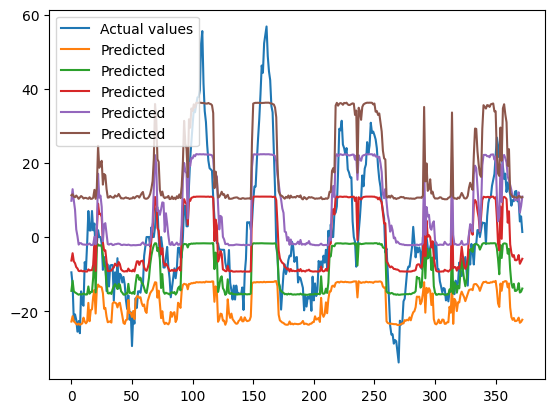

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


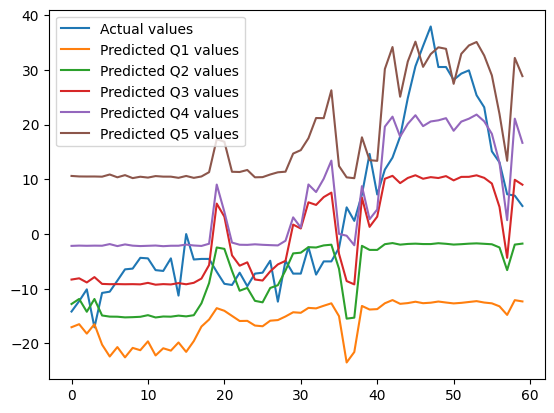

R1 for q0.05: 3.940851749744101
R1 for q0.25: 4.466474023588429
R1 for q0.5: 28.222964929536076
R1 for q0.75: 56.417316898971194
R1 for q0.95: 85.75738597288385
Mean R1: 35.76099871494473
R2 score: -49.888948327913866


In [117]:
y_pred = model.predict(X_train_rnn)
plot_and_evaluate_train_predictions(
    y_pred=y_pred, 
    y_true=mq_y_train_rnn[:,0].flatten()
    )

y_pred = model.predict(X_test_rnn)
mean_pred = y_pred @ np.array([0.15, 0.225, 0.25, 0.225, 0.15]).reshape(-1,1)
plot_and_evaluate_train_predictions(
    y_pred=y_pred,
    y_true=mq_y_test_rnn[:,0].flatten(),
    multi_quantile=True
    )

y_full = pd.concat([y_train_full, y_test])
q_benchmarks = pd.DataFrame()
for i, q in enumerate(QUANTILES):
    # We need to lag the y_full array because it is currently ahead by 4q
    q_benchmark = y_full.shift(12).rolling(window=12).quantile(q)
    q_benchmarks[f'q{q}'] = q_benchmark
q_benchmarks = q_benchmarks.values[-y_test.shape[0]:]

mean_benchmark = y_full.rolling(window=12).mean().values.flatten()[-y_test.shape[0]:]
evaluate_quantile_predictions(
    y_pred, 
    y_test_rnn,
    q_benchmarks=q_benchmarks,
    mean_benchmark=mean_benchmark
)

In [104]:
TARGET_IDX

2

In [112]:
evaluate_quantile_predictions(
    q_benchmarks,
    y_test_rnn,
    q_benchmarks,
    mean_benchmark
)

R1 for q0.05: 0.0
R1 for q0.25: 0.0
R1 for q0.5: 0.0
R1 for q0.75: 0.0
R1 for q0.95: 0.0
Mean R1: 0.0
R2 score: -270.73738432770415


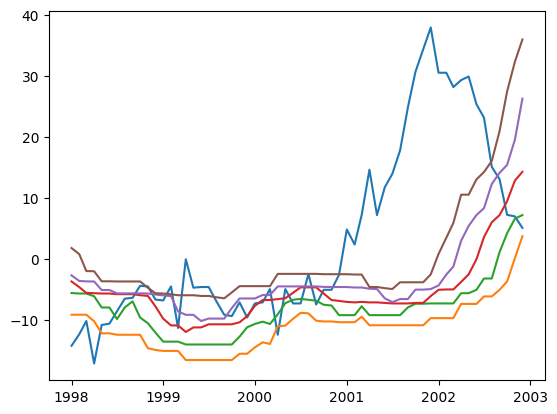

In [113]:
plt.plot(y_test)
plt.plot(y_test.index, q_benchmarks)

# Old DMQ function

In [ ]:
keras.utils.set_random_seed(1)

model = build_dmq_v0(
    input_shape=X_train_rnn.shape[1:],
    n_recurrent_layers=2,
    n_shared_layers=2,
    n_qtask_layers=2,
    n_recurrent_nodes=32,
    n_shared_nodes=16,
    n_task_nodes=8,
    lr=1e-3,
    dropout=0.0,
    rec_drop=0.0,
    l2=1e-3,
    recurrent_layer_type='lstm',
    lower_quantiles=[0.05, 0.25], 
    upper_quantiles=[0.75, 0.95],
    recurrent_norm=True,
    shared_norm=True,
    task_norm=True,
    # loss_weights=[0.28, 0.17, 0.11, 0.17, 0.28]
    loss_weights=[1/5]*5
)


early_stopping = EarlyStopping(
    monitor='val_loss',
    min_delta=1e-3,
    patience=5
)

history = model.fit(
    X_train_rnn,
    mq_y_train_rnn,
    epochs=200,
    batch_size=8,
    validation_data=(X_val_rnn, mq_y_val_rnn),
    callbacks=[
        early_stopping
    ],
    verbose=1,
    shuffle=True
)

pd.DataFrame(history.history).plot()

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


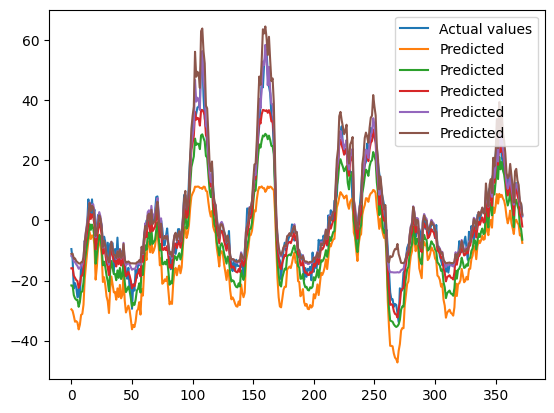

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


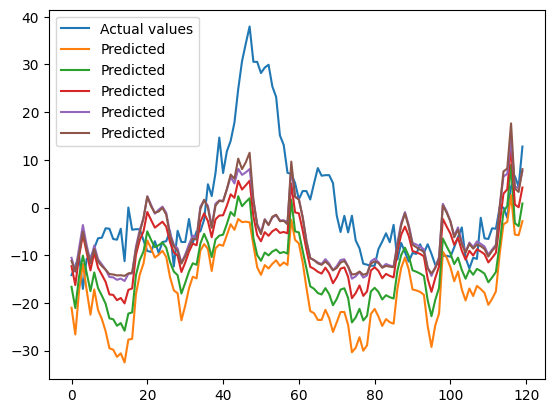

R1 for q0.05: 99.49752752920297
R1 for q0.25: 99.10359409718545
R1 for q0.5: 98.99091977818674
R1 for q0.75: 98.77157273724137
R1 for q0.95: 97.64680356915623
Mean R1: 98.80208354219457
R2 score: 99.98461032629116


In [58]:
y_pred = model.predict(X_train_rnn)
plot_and_evaluate_train_predictions(
    y_pred=y_pred, 
    y_true=mq_y_train_rnn[:,0].flatten()
    )

y_pred = model.predict(X_test_rnn)
mean_pred = y_pred @ np.array([0.15, 0.225, 0.25, 0.225, 0.15]).reshape(-1,1)
plot_and_evaluate_train_predictions(
    y_pred=y_pred,
    y_true=mq_y_test_rnn[:,0].flatten()
    )

y_full = pd.concat([y_train_full, y_test])
q_benchmarks = pd.DataFrame()
for i, q in enumerate(QUANTILES):
    q_benchmark = y_full.rolling(window=12).quantile(q)
    q_benchmarks[f'q{q}'] = q_benchmark
q_benchmarks = q_benchmarks.values[-y_test.shape[0]:]

mean_benchmark = y_full.rolling(window=12).mean().values.flatten()[-y_test.shape[0]:]
evaluate_quantile_predictions(
    y_pred, 
    y_test_rnn,
    q_benchmarks=q_benchmarks,
    mean_benchmark=mean_benchmark
)